In [14]:
import matplotlib.pyplot as plt
import pandas as pd

import numpy as np
import statsmodels.api as sm
from numpy.typing import NDArray

from utils_analysis_var_decomp import (
    between_within_var_breakdown,
)
from utils_analysis_features import load_all_features
from utils import open_folder
from scipy.stats import spearmanr  # type: ignore

In [15]:
def run_ols(  # type: ignore
    X: NDArray[np.floating] | pd.DataFrame,
    Y: NDArray[np.floating] | pd.DataFrame,
    use_reg: bool = False,
):
    X = sm.add_constant(X)  # type: ignore
    model = sm.OLS(Y, X)
    if use_reg:
        results = model.fit_regularized(method="elastic_net", alpha=0.0, L1_wt=1.0)  # type: ignore
    else:
        results = model.fit()  # type: ignore
    return results  # type: ignore

## Feature OLS

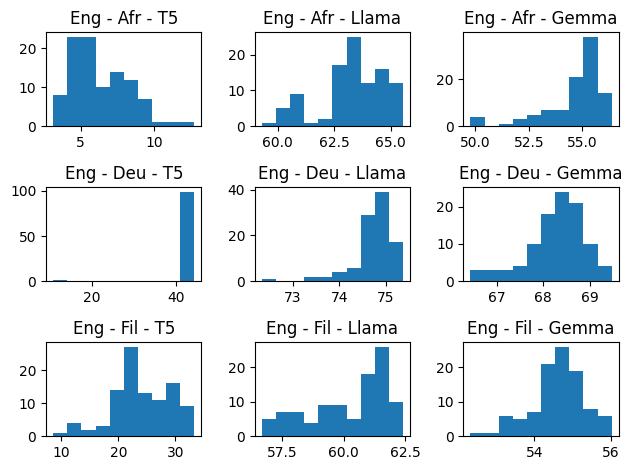

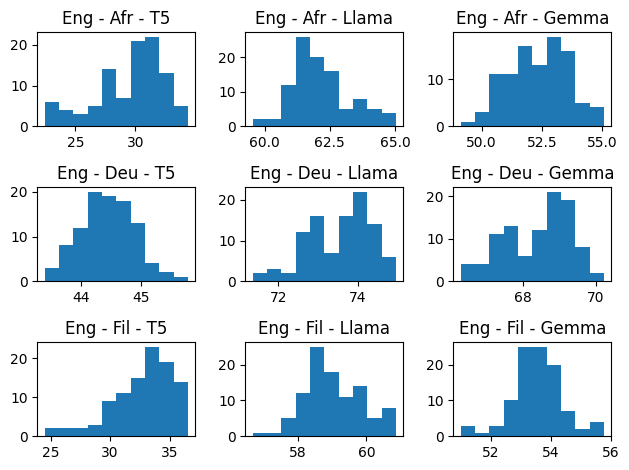

In [31]:
fig_100, ax_100 = plt.subplots(3, 3)
fig_500, ax_500 = plt.subplots(3, 3)

records = []
for task_idx, task in enumerate(["eng_afr", "eng_deu", "eng_fil"]):
    for model_idx, model in enumerate(["t5", "llama", "gemma"]):
        for num_dp_idx, num_datapoint in enumerate([100, 500]):
            df_sampling = load_all_features(
                task_name=task,
                model_name=model,
                num_samples=100,
                num_shuffles=1,
                num_datapoints=num_datapoint,
            )
            record = {
                "task": task,
                "model": model,
                "num_datapoint": num_datapoint,
            }
            columns = [
                c
                for c in df_sampling.columns
                if (c != "indices") and (c != "epoch") and (not c.startswith("eval_"))
            ]
            for col in columns:
                corr, pval = spearmanr(df_sampling[col], df_sampling["eval_chrf"])
                record[f"corr_{col}"] = (
                    f"{corr:.4f}{'*' if pval < (0.05 / len(columns)) else ''}"
                )
            rsq = run_ols(
                X=df_sampling[
                    [
                        "vocab_size",
                        "source_delfy_mean",
                        "target_delfy_mean",
                        "baseline_avg_l2_from_center",
                        "avg_log_token_prob_mean",
                        "avg_token_entropy_mean",
                        "beam_search_impt_mean",
                        "beam_search_ratio_mean",
                        "dropout_bald_mean",
                        "dropout_meteor_var_mean",
                        "dropout_disagreement_mean",
                    ]
                ]
                .map(lambda x: 0 if x in [np.inf, -np.inf] else x)
                .values,
                Y=df_sampling["eval_chrf"].values,
            ).rsquared
            record["r_squared"] = rsq
            records.append(record)

            if num_datapoint == 100:
                ax_100[task_idx, model_idx].hist(df_sampling["eval_chrf"])
                ax_100[task_idx, model_idx].set_title(
                    f"{task.replace('_', ' - ').title()} - {model.title()}"
                )
            elif num_datapoint == 500:
                ax_500[task_idx, model_idx].hist(df_sampling["eval_chrf"])
                ax_500[task_idx, model_idx].set_title(
                    f"{task.replace('_', ' - ').title()} - {model.title()}"
                )

fig_100.tight_layout()
fig_500.tight_layout()

In [32]:
df_feature_correlations = pd.DataFrame(records)

In [33]:
pd.melt(
    df_feature_correlations, id_vars=["task", "model", "num_datapoint"]
).pivot_table(
    columns=["task", "model", "num_datapoint"],
    index="variable",
    values="value",
    aggfunc="first",
).to_csv(
    "al_feature_corrs.csv"
)

## Var Decomp

In [2]:
for task in ["eng_afr", "eng_deu", "eng_fil"]:
    for model_name in ["t5", "llama", "gemma"]:
        try:
            var_decomp_result = open_folder(
                task_name=task,
                model_name=model_name,
                num_samples=10,
                num_shuffles=10,
                num_datapoints=100,
            )
        except FileNotFoundError:
            print(f"File not found for Task: {task}, Model: {model_name}")
            continue
        chrfs_by_trial = [
            [shuffle["eval_chrf"] for shuffle in trial["eval_metrics"]]
            for trial in var_decomp_result
        ]
        var_decomp = between_within_var_breakdown(chrfs_by_trial, G=10, N=10)
        print(
            f"Task: {task}, Model: {model_name}, % Within: {var_decomp['ss_within'] / var_decomp['ss_total']:.2f}"
        )

Task: eng_afr, Model: t5, % Within: 0.81
Task: eng_afr, Model: llama, % Within: 0.71
Task: eng_afr, Model: gemma, % Within: 0.80
Task: eng_deu, Model: t5, % Within: 0.83
Task: eng_deu, Model: llama, % Within: 0.81
Task: eng_deu, Model: gemma, % Within: 0.53
Task: eng_fil, Model: t5, % Within: 0.75
Task: eng_fil, Model: llama, % Within: 0.90
Task: eng_fil, Model: gemma, % Within: 0.71
